# Machine Learning for CICY 4-Folds

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import os
import time
import gzip
from IPython.display import Image
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score
from tensorflow import keras

import warnings
warnings.filterwarnings('ignore', message='The objective has been evaluated at this point before.')

# set matplot
sns.set()
PREFIX = 'cicy4_'
SUFFIX = '_inception'

# set memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)
        
# set random seed
RAND = 123
np.random.seed(RAND)
tf.random.set_seed(RAND)

In [2]:
proot = lambda s: os.path.join('.', s)
pdata = lambda s: os.path.join(proot('data'), s)
pimg  = lambda s: os.path.join(proot('img'), s)
ppred = lambda s: os.path.join(proot('pred'), s)

os.makedirs(proot('data'), exist_ok=True)
os.makedirs(proot('img'), exist_ok=True)
os.makedirs(proot('pred'), exist_ok=True)

## Download and Read the Dataset

In [3]:
data = keras.utils.get_file('cicy4.json.gz',
                            'https://www.lpthe.jussieu.fr/~erbin/files/data/cicy4.json.gz',
                            cache_dir='.',
                            cache_subdir='data'
                           )

## Reading the Dataset

In [4]:
df = pd.read_json(pdata('cicy4.json.gz'), orient='index')

In [5]:
# select only non product manifolds
df = df.loc[df['isprod'] == False]

# select only complete entries
df = df.dropna()

In [6]:
# get the max shape of the matrix
shape = df['size'].max()

# get the offset and pad the matrix
offset = lambda s: [(0, shape[i] - np.shape(s)[i]) for i in range(len(shape))]
df['matrix'] = df['matrix'].apply(lambda s: np.pad(s, offset(s), mode='constant'))

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 905684 entries, 1 to 921497
Data columns (total 9 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   euler   905684 non-null  int64  
 1   favour  905684 non-null  bool   
 2   h11     905684 non-null  float64
 3   h21     905684 non-null  float64
 4   h22     905684 non-null  float64
 5   h31     905684 non-null  float64
 6   isprod  905684 non-null  bool   
 7   matrix  905684 non-null  object 
 8   size    905684 non-null  object 
dtypes: bool(2), float64(4), int64(1), object(2)
memory usage: 57.0+ MB


In [8]:
df.head(5)

,euler,favour,h11,h21,h22,h31,isprod,matrix,size
1,2610,True,1.0,0.0,1752.0,426.0,False,"[[6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[1, 1]"
2,2190,True,1.0,0.0,1472.0,356.0,False,"[[2, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[1, 2]"
3,1476,True,1.0,0.0,996.0,237.0,False,"[[3, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[1, 2]"
4,1632,True,1.0,0.0,1100.0,263.0,False,"[[2, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[1, 3]"
5,1206,True,1.0,0.0,816.0,192.0,False,"[[2, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[1, 3]"


## Plots

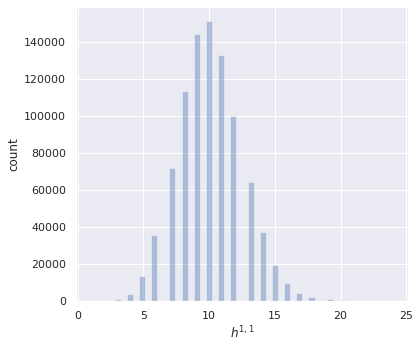

In [9]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(df['h11'],
             kde=False,
             ax=ax
            )
ax.set_xlabel('$h^{1,1}$')
ax.set_ylabel('count')

plt.tight_layout()
plt.savefig(pimg('h11_distribution.pdf'), format='pdf', dpi=150)

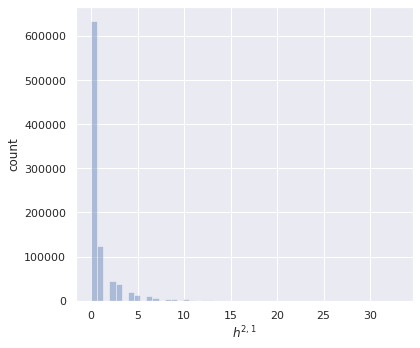

In [10]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(df['h21'],
             kde=False,
             ax=ax
            )
ax.set_xlabel('$h^{2,1}$')
ax.set_ylabel('count')

plt.tight_layout()
plt.savefig(pimg('h21_distribution.pdf'), format='pdf', dpi=150)

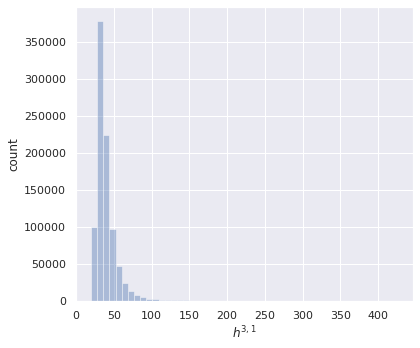

In [11]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(df['h31'],
             kde=False,
             ax=ax
            )
ax.set_xlabel('$h^{3,1}$')
ax.set_ylabel('count')

plt.tight_layout()
plt.savefig(pimg('h31_distribution.pdf'), format='pdf', dpi=150)

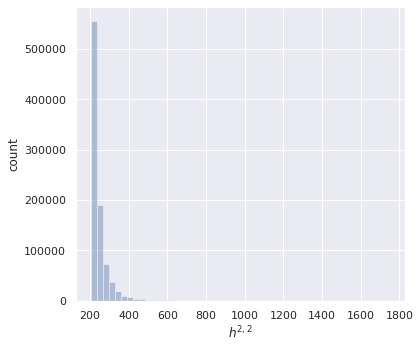

In [12]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(df['h22'],
             kde=False,
             ax=ax
            )
ax.set_xlabel('$h^{2,2}$')
ax.set_ylabel('count')

plt.tight_layout()
plt.savefig(pimg('h22_distribution.pdf'), format='pdf', dpi=150)

## Train, Validation, Test Splits

In [13]:
batch_size = 64

In [14]:
df_train, df_test = train_test_split(df, test_size=0.05, shuffle=True, random_state=RAND)
df_val, df_test   = train_test_split(df_test, test_size=0.5, shuffle=True, random_state=RAND)

print(f'Training set:   {df_train.shape[0]:d} samples (fraction: {df_train.shape[0] / df.shape[0]:.3f})')
print(f'Validation set: {df_val.shape[0]:d} samples (fraction: {df_val.shape[0] / df.shape[0]:.3f})')
print(f'Test set:       {df_test.shape[0]:d} samples (fraction: {df_test.shape[0] / df.shape[0]:.3f})')

Training set:   860399 samples (fraction: 0.950)
Validation set: 22642 samples (fraction: 0.025)
Test set:       22643 samples (fraction: 0.025)


## Remove Outliers from Train Set

In [15]:
low_quantile  = 0.05
high_quantile = 0.95

quantile = df_train.quantile(q=[low_quantile, high_quantile])

In [16]:
df_train = df_train.loc[(df_train['h11'] >= quantile['h11'].loc[low_quantile]) & (df_train['h11'] <= quantile['h11'].loc[high_quantile])
                        & (df_train['h21'] >= quantile['h21'].loc[low_quantile]) & (df_train['h21'] <= quantile['h21'].loc[high_quantile])
                        & (df_train['h31'] >= quantile['h31'].loc[low_quantile]) & (df_train['h31'] <= quantile['h31'].loc[high_quantile])
                        & (df_train['h22'] >= quantile['h22'].loc[low_quantile]) & (df_train['h22'] <= quantile['h22'].loc[high_quantile])
                       ]
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 737465 entries, 312673 to 788943
Data columns (total 9 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   euler   737465 non-null  int64  
 1   favour  737465 non-null  bool   
 2   h11     737465 non-null  float64
 3   h21     737465 non-null  float64
 4   h22     737465 non-null  float64
 5   h31     737465 non-null  float64
 6   isprod  737465 non-null  bool   
 7   matrix  737465 non-null  object 
 8   size    737465 non-null  object 
dtypes: bool(2), float64(4), int64(1), object(2)
memory usage: 46.4+ MB


## Rescale the Matrices

In [17]:
scale = df_train['matrix'].apply(np.max).max()

In [18]:
df_train['matrix'] = df_train['matrix'] / scale
df_val['matrix']   = df_val['matrix'] / scale
df_test['matrix']  = df_test['matrix'] / scale

## Reshape Layers for CNN

In [19]:
reshape = tuple(shape + [1])

In [20]:
df_train['matrix'] = df_train['matrix'].apply(lambda x: np.reshape(x, reshape))
df_val['matrix']   = df_val['matrix'].apply(lambda x: np.reshape(x, reshape))
df_test['matrix']  = df_test['matrix'].apply(lambda x: np.reshape(x, reshape))

## Create Dataset Generators

In [21]:
train_labels = {'h11': list(df_train['h11'].values.astype(np.int)),
                'h21': list(df_train['h21'].values.astype(np.int)),
                'h31': list(df_train['h31'].values.astype(np.int)),
                'h22': list(df_train['h22'].values.astype(np.int)),
               }
val_labels = {'h11': list(df_val['h11'].values.astype(np.int)),
              'h21': list(df_val['h21'].values.astype(np.int)),
              'h31': list(df_val['h31'].values.astype(np.int)),
              'h22': list(df_val['h22'].values.astype(np.int)),
             }
test_labels = {'h11': list(df_test['h11'].values.astype(np.int)),
               'h21': list(df_test['h21'].values.astype(np.int)),
               'h31': list(df_test['h31'].values.astype(np.int)),
               'h22': list(df_test['h22'].values.astype(np.int)),
              }

In [22]:
train = tf.data.Dataset.from_tensor_slices((list(df_train['matrix'].values),
                                            train_labels
                                           )
                                          ).batch(batch_size).prefetch(2 * batch_size)
val = tf.data.Dataset.from_tensor_slices((list(df_val['matrix'].values),
                                          val_labels
                                         )
                                        ).batch(batch_size).prefetch(2 * batch_size)
test = tf.data.Dataset.from_tensor_slices((list(df_test['matrix'].values),
                                           test_labels
                                          )
                                         ).batch(batch_size).prefetch(2 * batch_size)

## Model Building

In [43]:
def nn_inception(input_shape,
                 name='inception',
                 learning_rate=1.0e-3,
                 conv_layers=[32, 64, 32],
                 conv_alpha=0.0,
                 fc_layers=[],
                 fc_alpha=0.0,
                 dropout=0.2,
                 full_dropout=0.0,
                 batchnorm=0.99,
                 last_relu=True,
                 loss_weights=[0.25, 0.25, 0.25, 0.25],
                 l1_reg=1.0e-5,
                 l2_reg=1.0e-5
                ):
    '''
    Create a Tensorflow model of the Inception Network.
    
    Arguments:
        input_shape: the shape of the input tensor.
        
    Optional:
        name:          the name of the model,
        learning_rate: the shrinking parameter of gradient descent,
        conv_layyers:  list of filters in convolutional layers,
        conv_alpha:    slope of the LeakyReLU activation of the convolutional layers,
        fc_layers:     list of units in the fully connected network,
        fc_alpha:      slope of the LeakyReLU activation of the fully connected layers,
        dropout:       dropout rate before the flatten layer,
        full_dropout:  dropout rate after every layer,
        batchnorm:     momentum of the batch normalisation,
        last_relu:     include ReLU in the output layers (if True),
        loss_weights:  the weights of the loss function,
        l1_reg:        l1 regularisation,
        l2_reg:        l2 regularisation.
        
    Returns:
        the Tensorflow compiled model.
    '''
    keras.backend.clear_session()
    
    I = keras.layers.Input(shape=input_shape, name='matrix')
    x = I
    
    # build convolutions
    for n in range(len(conv_layers)):
        a = keras.layers.Conv2D(conv_layers[n],
                                kernel_size=(x.shape[1], 1),
                                padding='same',
                                kernel_regularizer=keras.regularizers.l1_l2(l1=l1_reg, l2=l2_reg)
                               )(x)
        a = keras.layers.LeakyReLU(conv_alpha)(a)
        
        b = keras.layers.Conv2D(conv_layers[n],
                                kernel_size=(1, x.shape[2]),
                                padding='same',
                                kernel_regularizer=keras.regularizers.l1_l2(l1=l1_reg, l2=l2_reg)
                               )(x)
        b = keras.layers.LeakyReLU(conv_alpha)(b)
        
        x = keras.layers.concatenate([a, b])
        if batchnorm > 0.0:
            x = keras.layers.BatchNormalization(momentum=batchnorm)(x)
        if full_dropout > 0.0:
            x = keras.layers.Dropout(rate=full_dropout)(x)
            
    # flatten and dropout
    x = keras.layers.Flatten()(x)
    if dropout > 0.0:
        x = keras.layers.Dropout(rate=dropout)(x)
    
    # fully connected network
    for n in range(len(fc_layers)):
        x = keras.layers.Dense(fc_layers[n],
                               kernel_regularizer=keras.regularizers.l1_l2(l1=l1_reg, l2=l2_reg)
                              )(x)
        x = keras.layers.LeakyReLU(fc_alpha)(x)
        if batchnorm > 0.0:
            x = keras.layers.BatchNormalization(momentum=batchnorm)(x)
        if full_dropout > 0.0:
            x = keras.layers.Dropout(rate=full_dropout)(x)
            
    # output layers
    if last_relu:
        O = {'h11': keras.layers.Dense(1, activation='relu', name='h11')(x),
             'h21': keras.layers.Dense(1, activation='relu', name='h21')(x),
             'h31': keras.layers.Dense(1, activation='relu', name='h31')(x),
             'h22': keras.layers.Dense(1, activation='relu', name='h22')(x),
            }
    else:
        O = {'h11': keras.layers.Dense(1, name='h11')(x),
             'h21': keras.layers.Dense(1, name='h21')(x),
             'h31': keras.layers.Dense(1, name='h31')(x),
             'h22': keras.layers.Dense(1, name='h22')(x),
            }
        
    # compile the model
    model = keras.models.Model(inputs=I, outputs=O, name=name)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                  loss=keras.losses.MeanSquaredError(),
                  loss_weights=loss_weights,
                  metrics=[keras.metrics.MeanSquaredError(),
                           keras.metrics.MeanAbsoluteError()
                          ]
                 )
    
    return model

In [44]:
inception = nn_inception(input_shape=reshape,
                         learning_rate=1.0e-3,
                         conv_layers=[64, 128, 16],
                         conv_alpha=0.0,
                         fc_layers=[],
                         fc_alpha=0.0,
                         dropout=0.2,
                         full_dropout=0.0,
                         batchnorm=0.99,
                         last_relu=True,
                         loss_weights=[0.25, 0.25, 0.25, 0.25],
                         l1_reg=1.0e-5,
                         l2_reg=1.0e-5
                        )

inception.summary()

Model: "inception"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
matrix (InputLayer)             [(None, 16, 20, 1)]  0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 16, 20, 64)   1088        matrix[0][0]                     
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 16, 20, 64)   1344        matrix[0][0]                     
__________________________________________________________________________________________________
leaky_re_lu (LeakyReLU)         (None, 16, 20, 64)   0           conv2d[0][0]                     
__________________________________________________________________________________________

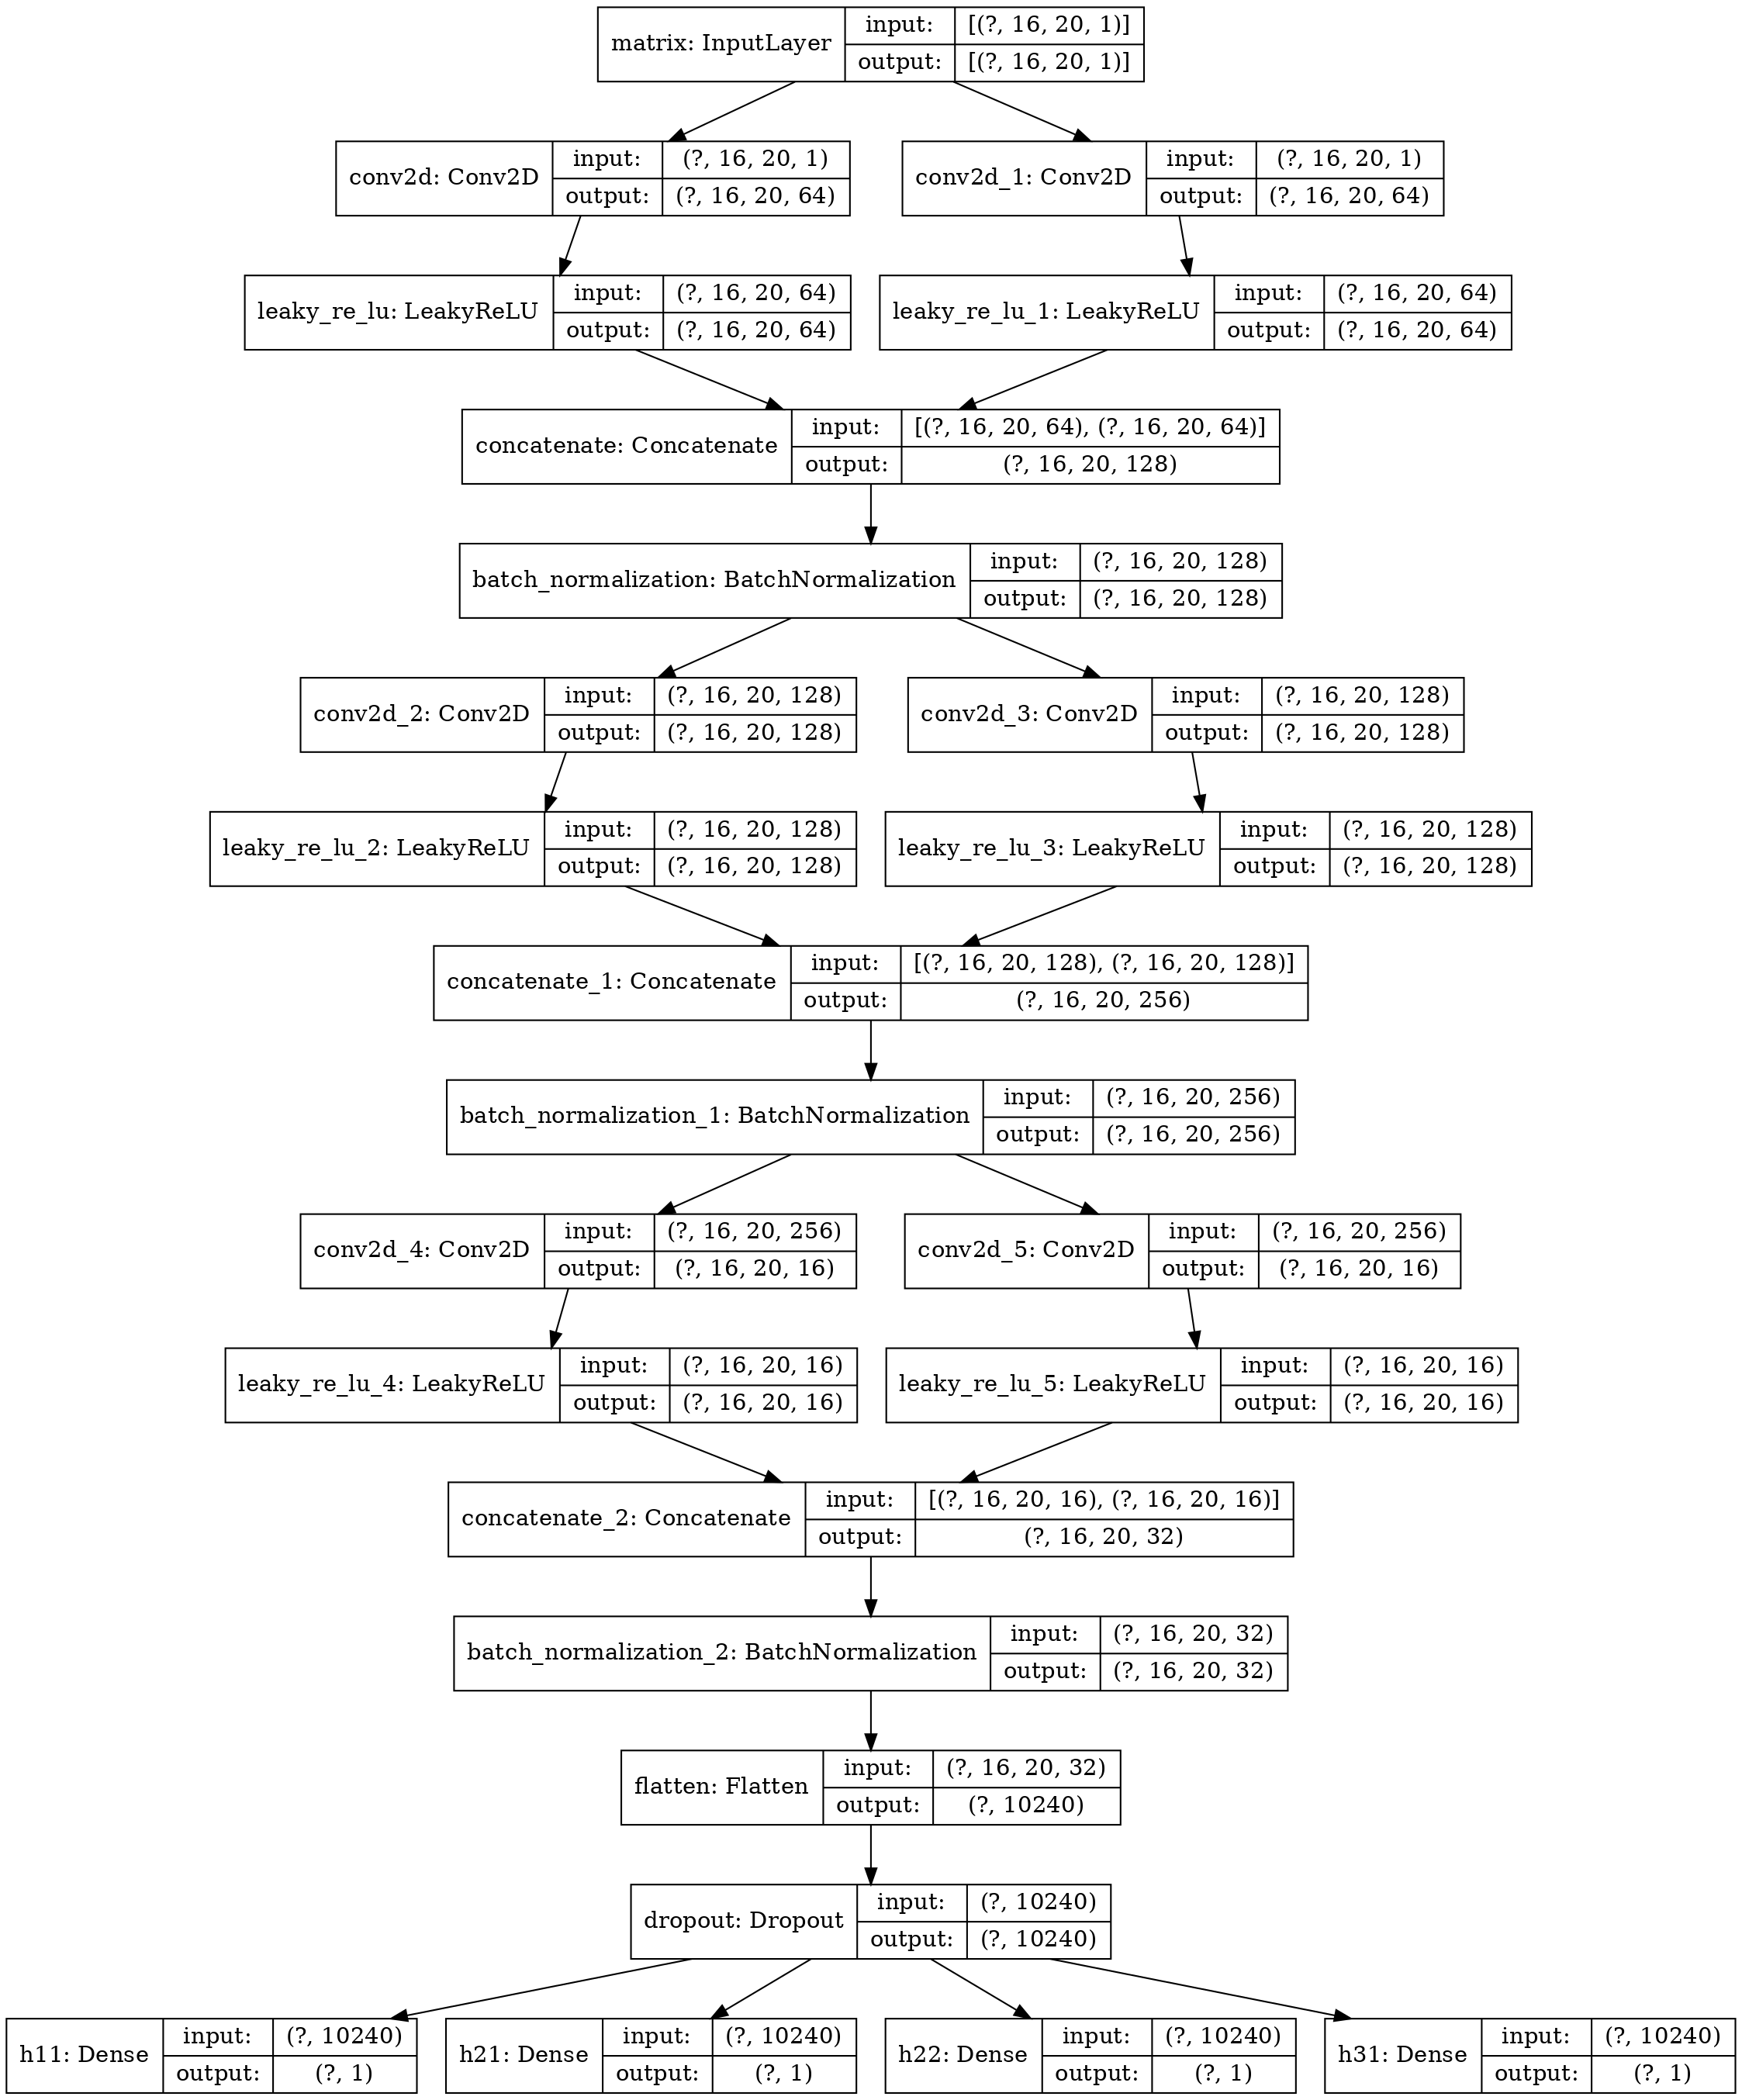

In [45]:
inception_graph = keras.utils.model_to_dot(inception, show_shapes=True, dpi=150)
inception_graph.write_pdf(pimg('inception_graph.pdf'))
Image(inception_graph.create_png(), width=480)

## Training the Model

In [26]:
epochs = 150

In [27]:
inception_hst = inception.fit(train,
                              batch_size=batch_size,
                              epochs=epochs,
                              verbose=0,
                              callbacks=[keras.callbacks.EarlyStopping(patience=50, restore_best_weights=True),
                                         keras.callbacks.ModelCheckpoint(pdata('inception.h5'), save_best_only=True),
                                         keras.callbacks.ReduceLROnPlateau(factor=0.3, patience=30, min_lr=1.0e-6)
                                        ],
                              validation_data=val
                             )

Epoch 1/5
11523/11523 [==============================] - 216s 19ms/step - loss: 35.1943 - h11_loss: 0.8331 - h21_loss: 1.4860 - h22_loss: 129.8392 - h31_loss: 7.6685 - h11_mean_squared_error: 0.8331 - h11_mean_absolute_error: 0.6761 - h21_mean_squared_error: 1.4860 - h21_mean_absolute_error: 0.5554 - h22_mean_squared_error: 129.8392 - h22_mean_absolute_error: 6.8354 - h31_mean_squared_error: 7.6685 - h31_mean_absolute_error: 1.9971 - val_loss: 72.2269 - val_h11_loss: 0.6568 - val_h21_loss: 4.2260 - val_h22_loss: 266.1569 - val_h31_loss: 16.4592 - val_h11_mean_squared_error: 0.6568 - val_h11_mean_absolute_error: 0.4748 - val_h21_mean_squared_error: 4.2260 - val_h21_mean_absolute_error: 0.8091 - val_h22_mean_squared_error: 266.1569 - val_h22_mean_absolute_error: 7.5676 - val_h31_mean_squared_error: 16.4592 - val_h31_mean_absolute_error: 2.1226 - lr: 0.0010
Epoch 2/5
11523/11523 [==============================] - 216s 19ms/step - loss: 10.3736 - h11_loss: 0.4413 - h21_loss: 1.4859 - h22_l

In [28]:
history = pd.DataFrame(inception_hst.history)

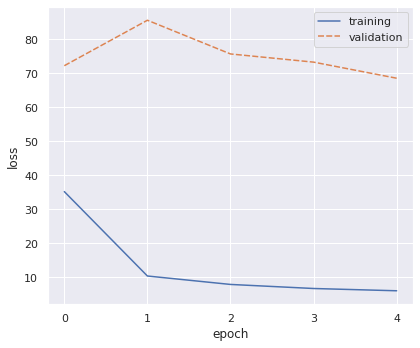

In [29]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.lineplot(data=history[['loss', 'val_loss']],
             ax=ax
            )
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax.set_xticks(range(epochs))
ax.legend(['training', 'validation'])

plt.tight_layout()
plt.savefig(pimg('loss_functions.pdf'), format='pdf', dpi=150)

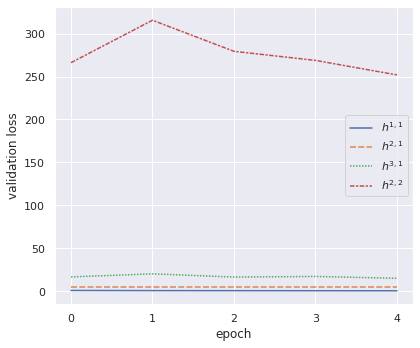

In [30]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.lineplot(data=history[['val_h11_loss', 'val_h21_loss', 'val_h31_loss', 'val_h22_loss']],
             ax=ax
            )
ax.set_xlabel('epoch')
ax.set_ylabel('validation loss')
ax.set_xticks(range(epochs))
ax.legend(['$h^{1,1}$', '$h^{2,1}$', '$h^{3,1}$', '$h^{2,2}$'])

plt.tight_layout()
plt.savefig(pimg('val_loss_functions.pdf'), format='pdf', dpi=150)

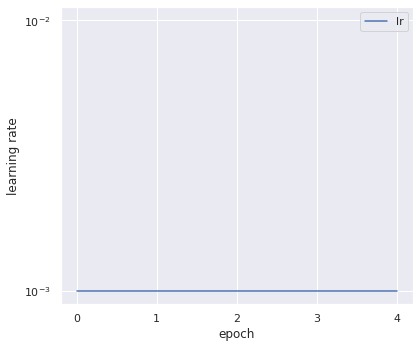

In [31]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.lineplot(data=history[['lr']],
             ax=ax
            )
ax.set_xlabel('epoch')
ax.set_ylabel('learning rate')
ax.set_yscale('log')
ax.set_xticks(range(epochs))

plt.tight_layout()
plt.savefig(pimg('learning_rate.pdf'), format='pdf', dpi=150)

## Computing Metrics and Predictions

In [32]:
train_predictions = inception.predict(train)
train_predictions = {key: list(np.rint(value.reshape(-1,)).astype(np.int)) for key, value in train_predictions.items()}
val_predictions   = inception.predict(val)
val_predictions   = {key: list(np.rint(value.reshape(-1,)).astype(np.int)) for key, value in val_predictions.items()}
test_predictions  = inception.predict(test)
test_predictions  = {key: list(np.rint(value.reshape(-1,)).astype(np.int)) for key, value in test_predictions.items()}

In [33]:
# compute metrics
metrics = {}
hodges  = ['h11', 'h21', 'h31', 'h22']
metrics['train_mse'] = [mean_squared_error(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_mse']   = [mean_squared_error(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_mse']  = [mean_squared_error(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_mae'] = [mean_absolute_error(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_mae']   = [mean_absolute_error(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_mae']  = [mean_absolute_error(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_r2']  = [r2_score(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_r2']    = [r2_score(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_r2']   = [r2_score(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_acc'] = [accuracy_score(train_labels[c], np.rint(train_predictions[c]).astype(np.int)) for c in hodges]
metrics['val_acc']   = [accuracy_score(val_labels[c], np.rint(val_predictions[c]).astype(np.int)) for c in hodges]
metrics['test_acc']  = [accuracy_score(test_labels[c], np.rint(test_predictions[c]).astype(np.int)) for c in hodges]

metrics = pd.DataFrame(metrics, index=hodges)
metrics

,train_mse,val_mse,test_mse,train_mae,val_mae,test_mae,train_r2,val_r2,test_r2,train_acc,val_acc,test_acc
h11,0.098001,0.300062,0.327298,0.090155,0.175868,0.184207,0.973372,0.948456,0.945066,0.913397,0.862247,0.858588
h21,1.485919,4.226040,4.214106,0.555382,0.809116,0.824184,-0.261960,-0.183310,-0.192168,0.712999,0.702411,0.698936
h31,0.897672,14.889674,13.732279,0.604834,1.109884,1.115753,0.986458,0.921011,0.926850,0.507320,0.458087,0.455770
h22,12.427300,251.956364,232.199399,2.487501,4.647823,4.680343,0.984524,0.897896,0.905211,0.152201,0.140005,0.138939


In [34]:
train_residuals = {key: np.subtract(train_labels[key], train_predictions[key]) for key in train_labels.keys()}
val_residuals   = {key: np.subtract(val_labels[key], val_predictions[key]) for key in val_labels.keys()}
test_residuals  = {key: np.subtract(test_labels[key], test_predictions[key]) for key in test_labels.keys()}

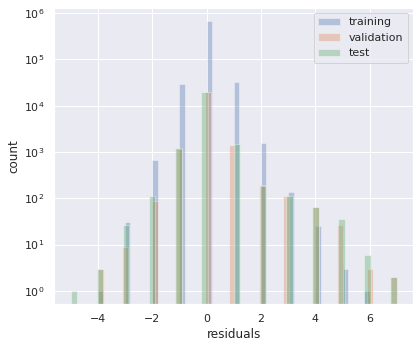

In [35]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(train_residuals['h11'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(val_residuals['h11'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(test_residuals['h11'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'])

plt.tight_layout()
plt.savefig(pimg('h11_residuals_hist.pdf'), format='pdf', dpi=150)

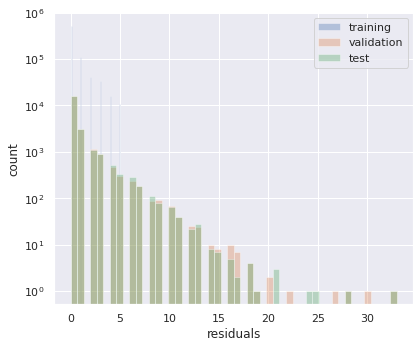

In [36]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(train_residuals['h21'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(val_residuals['h21'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(test_residuals['h21'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'])

plt.tight_layout()
plt.savefig(pimg('h21_residuals_hist.pdf'), format='pdf', dpi=150)

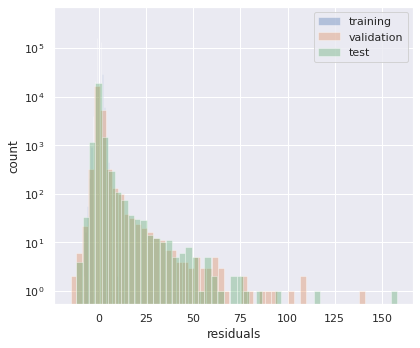

In [37]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(train_residuals['h31'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(val_residuals['h31'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(test_residuals['h31'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'])

plt.tight_layout()
plt.savefig(pimg('h31_residuals_hist.pdf'), format='pdf', dpi=150)

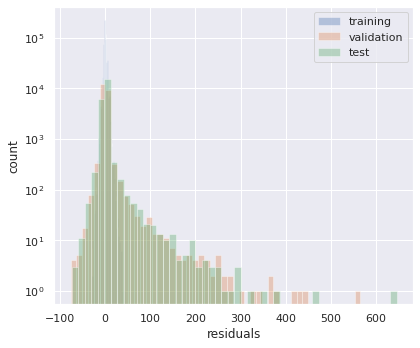

In [38]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.distplot(train_residuals['h22'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(val_residuals['h22'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
sns.distplot(test_residuals['h22'],
             kde=False,
             hist_kws={'alpha': 0.35},
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'])

plt.tight_layout()
plt.savefig(pimg('h22_residuals_hist.pdf'), format='pdf', dpi=150)

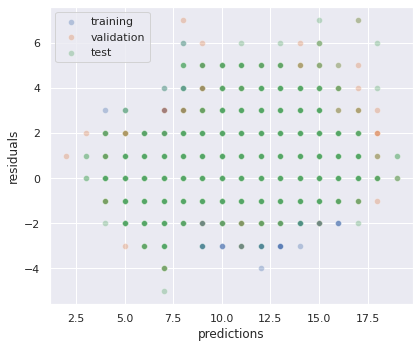

In [39]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h11'],
                y=train_residuals['h11'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h11'],
                y=val_residuals['h11'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h11'],
                y=test_residuals['h11'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residuals')
ax.legend(['training', 'validation', 'test'])

plt.tight_layout()
plt.savefig(pimg('h11_residuals.pdf'), format='pdf', dpi=150)

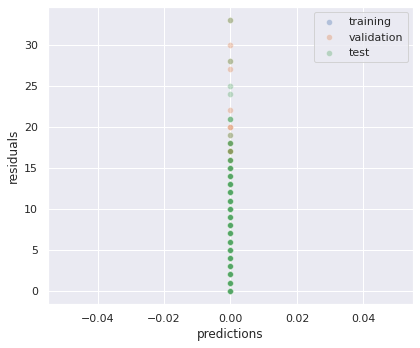

In [40]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h21'],
                y=train_residuals['h21'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h21'],
                y=val_residuals['h21'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h21'],
                y=test_residuals['h21'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residuals')
ax.legend(['training', 'validation', 'test'])

plt.tight_layout()
plt.savefig(pimg('h21_residuals.pdf'), format='pdf', dpi=150)

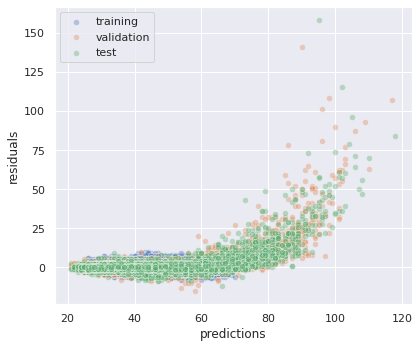

In [41]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h31'],
                y=train_residuals['h31'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h31'],
                y=val_residuals['h31'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h31'],
                y=test_residuals['h31'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residuals')
ax.legend(['training', 'validation', 'test'])

plt.tight_layout()
plt.savefig(pimg('h31_residuals.pdf'), format='pdf', dpi=150)

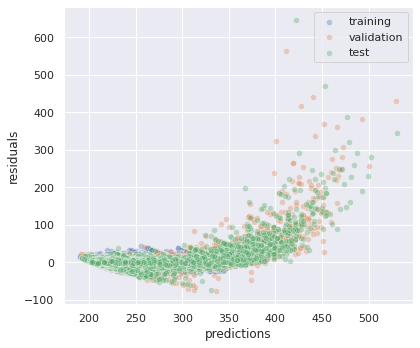

In [42]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h22'],
                y=train_residuals['h22'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h22'],
                y=val_residuals['h22'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h22'],
                y=test_residuals['h22'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residuals')
ax.legend(['training', 'validation', 'test'])

plt.tight_layout()
plt.savefig(pimg('h22_residuals.pdf'), format='pdf', dpi=150)